In [123]:
from dataset_gbm import GBMGenerativeDataset, estimate_parameters, reverse_log_return, HestonGenerativeDataset
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import norm


plt.style.use('seaborn-v0_8')

In [124]:
# !python generate.py --seeds=0-9999 \
#                     --network=out_train_ts/00038-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-ao6pE/network-snapshot-002500.pkl \
#                     --outdir=out_train_ts/00038-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-ao6pE/generated_samples \
#                     --batch=64

In [125]:
# !python generate.py --seeds=0-9999 \
#                     --network=out_train_ts/00040-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-DZ3U5/network-snapshot-002500.pkl \
#                     --outdir=out_train_ts/00040-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-DZ3U5/generated_samples \
#                     --batch=64

In [126]:
# !python generate.py --seeds=0-9999 \
#                     --network=out_train_ts/00041-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-42HA2/network-snapshot-002500.pkl \
#                     --outdir=out_train_ts/00041-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-42HA2/generated_samples \
#                     --batch=64

In [127]:
# Parameters
n_paths = 50000
n_steps = 128
mu = 0.3
sigma = 0.1
GENERATE_LOG_RETURNS = True
stochastic_model = 'Heston'

if stochastic_model == 'Heston':
    #Heston parameters
    kappa = 1.0
    theta = 0.1
    sigma_v = 0.1
    rho = 0.5
    v0 = 0.01

K=110

In [128]:
def price_option(paths, K, r, T, M):
    terminal_prices = paths[-1, :]
    payoffs = np.maximum(terminal_prices - K, 0)
    option_prices = payoffs * np.exp(-r * T)
    estimated_price = np.mean(option_prices)
    std_err = np.std(option_prices) / np.sqrt(M)
    return estimated_price, std_err, option_prices

def price_option_bs(S0, K, r, sigma, T):

    # Black-Scholes formula components
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Calculate the call option price using the Black-Scholes formula
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


In [129]:
# dataset = GBMGenerativeDataset(n_paths=10000, n_steps=200, mu=0.3, sigma=0.1)
# paths = dataset.paths.squeeze()
# estimated_price, _, _ = price_option(paths=paths.T, K=110, r=0.3, T=1.0, M=10000)
# bs_price = price_option_bs(S0=100, K=110, r=0.3, sigma=0.1, T=1)
# bs_price, estimated_price

In [130]:
def process_data(generated_filepath, normalization, stochastic_model='GBM'):
    # Generate dataset
    if stochastic_model == 'GBM':
        dataset = GBMGenerativeDataset(n_paths=n_paths, n_steps=n_steps, mu=mu, sigma=sigma,
                                   return_log_returns=GENERATE_LOG_RETURNS)
    else:
        dataset = HestonGenerativeDataset(
            mu=mu,
            n_steps=n_steps,
            n_paths=n_paths,
            kappa=kappa,
            theta=theta,
            sigma_v=sigma_v,
            rho=rho,
            v0=v0,
            return_log_returns=GENERATE_LOG_RETURNS,
        )
    real = dataset.paths.squeeze()
    generated = np.load(generated_filepath)
    if normalization == 'global_mean':
        generated_unnorm = generated * np.mean(real)
    elif normalization == 'global_zscore':
        generated_unnorm = generated * np.std(real) + np.mean(real)
    elif normalization is None:
        generated_unnorm = generated
    else:
        raise NotImplemented
    # Reverse log returns to obtain price paths
    if GENERATE_LOG_RETURNS:
        real_gbm = reverse_log_return(real, s0=100)
        generated_gbm = reverse_log_return(generated_unnorm, s0=100)
    else:
        real_gbm = real
        generated_gbm = generated_unnorm
    # Estimate parameters
    mu_real, sigma_real = estimate_parameters(real_gbm, dataset.dt)
    mu_gen, sigma_gen = estimate_parameters(generated_gbm, dataset.dt)

    # Price options
    estimated_price_real, std_err_real, _ = price_option(paths=real_gbm.T, K=K, r=mu, T=1.0, M=n_paths)
    estimated_price_gen, std_err_gen, _ = price_option(paths=generated_gbm.T, K=K, r=mu, T=1.0, M=n_paths)
    bs_price = price_option_bs(S0=100, K=K, r=mu, sigma=sigma, T=1.0)


    # Create figure with subplots
    fig, axes = plt.subplots(4, 2, figsize=(12, 16))
    # Plot 1: Real Paths
    for path in real[:100]:
        axes[0, 0].plot(path, alpha=0.5)
    axes[0, 0].set_title("Real Paths")

    # Plot 2: Generated Paths
    for path in generated_unnorm[:100]:
        axes[0, 1].plot(path, alpha=0.5)
    axes[0, 1].set_title("Generated Paths")

    # Plot 3: Real GBM Paths
    for path in real_gbm[:100]:
        axes[1, 0].plot(path, alpha=0.5)
    axes[1, 0].set_title("Real GBM Paths")

    # Plot 4: Generated GBM Paths
    for path in generated_gbm[:100]:
        axes[1, 1].plot(path, alpha=0.5)
    axes[1, 1].set_title("Generated GBM Paths")

    # Plot 5: KDE of Estimated Drift (Mu)
    sns.kdeplot(mu_real, label='real mu', fill=True, ax=axes[2, 0])
    sns.kdeplot(mu_gen, label='generated mu', fill=True, ax=axes[2, 0])
    # axes[2, 0].set_xlim(-0.2, 1.0)
    axes[2, 0].legend()
    axes[2, 0].set_title("KDE of Estimated Drift (Mu)")

    # Plot 6: KDE of Estimated Volatility (Sigma)
    sns.kdeplot(sigma_real, label='real sigma', fill=True, ax=axes[2, 1])
    sns.kdeplot(sigma_gen, label='generated sigma', fill=True, ax=axes[2, 1])
    # axes[2, 1].set_xlim(0, 0.2)
    axes[2, 1].legend()
    axes[2, 1].set_title("KDE of Estimated Volatility (Sigma)")

    # Plot 7: KDE of Log Returns
    sns.kdeplot(real.flatten(), label='real', fill=True, ax=axes[3, 0])
    sns.kdeplot(generated_unnorm.flatten(), label='generated', fill=True, ax=axes[3, 0])
    axes[3, 0].legend()
    axes[3, 0].set_title("KDE of Log Returns")

    # Add parameters and option pricing as text in the figure
    # params_text = (f"n_paths={n_paths}\nn_steps={n_steps}\nmu={mu}\nsigma={sigma}\n\n\n\n"
    #                f"BS Price={bs_price:.3f}\n"
    #                f"Real Option Price={estimated_price_real:.3f} ± {1.96 * std_err_real:.3f}\n"
    #                f"Generated Option Price={estimated_price_gen:.3f} ± {1.96 * std_err_gen:.3f}")
    if stochastic_model == 'Heston':
        params_str = (
        r"$n_{paths} = 50,000$" "\n"
        r"$n_{steps} = 128$" "\n"
        r"$\mu = 0.3$" "\n"
        r"$\kappa = 1.0$" "\n"
        r"$\theta = 0.1$" "\n"
        r"$\sigma_v = 0.1$" "\n"
        r"$\rho = 0.5$" "\n"
        r"$v_0 = 0.01$" "\n\n\n"
        )
        params_text = params_str + (
               f"Real Option Price={estimated_price_real:.3f} ± {1.96 * std_err_real:.3f}\n"
               f"Generated Option Price={estimated_price_gen:.3f} ± {1.96 * std_err_gen:.3f}"
        )

    axes[3, 1].text(0.5, 0.5, params_text, fontsize=12, ha='center', va='center', bbox={"facecolor": "white", "alpha": 0.5, "pad": 5})
    axes[3, 1].set_axis_off()

    realized_volatility = np.sqrt(np.mean(real**2, axis=0)*n_steps)
    realized_volatility_generated = np.sqrt(np.mean(generated_unnorm**2, axis=0)*n_steps)
    plt.figure(figsize=(10, 5))
    plt.plot(np.mean(dataset.variances, axis=0), label='True Variance (Heston)')
    plt.plot(realized_volatility**2, label='Realized Volatility (Heston)')
    plt.plot(realized_volatility_generated**2, label='Realized Volatility (Generated)')
    plt.legend()
    plt.title('True vs. estimated volatility (Heston) vs estimated volatility (generated)')
    plt.xlabel('Time Steps')
    plt.ylabel('Volatility')



    # Adjust layout
    plt.tight_layout()

    # Show plot
    plt.show()

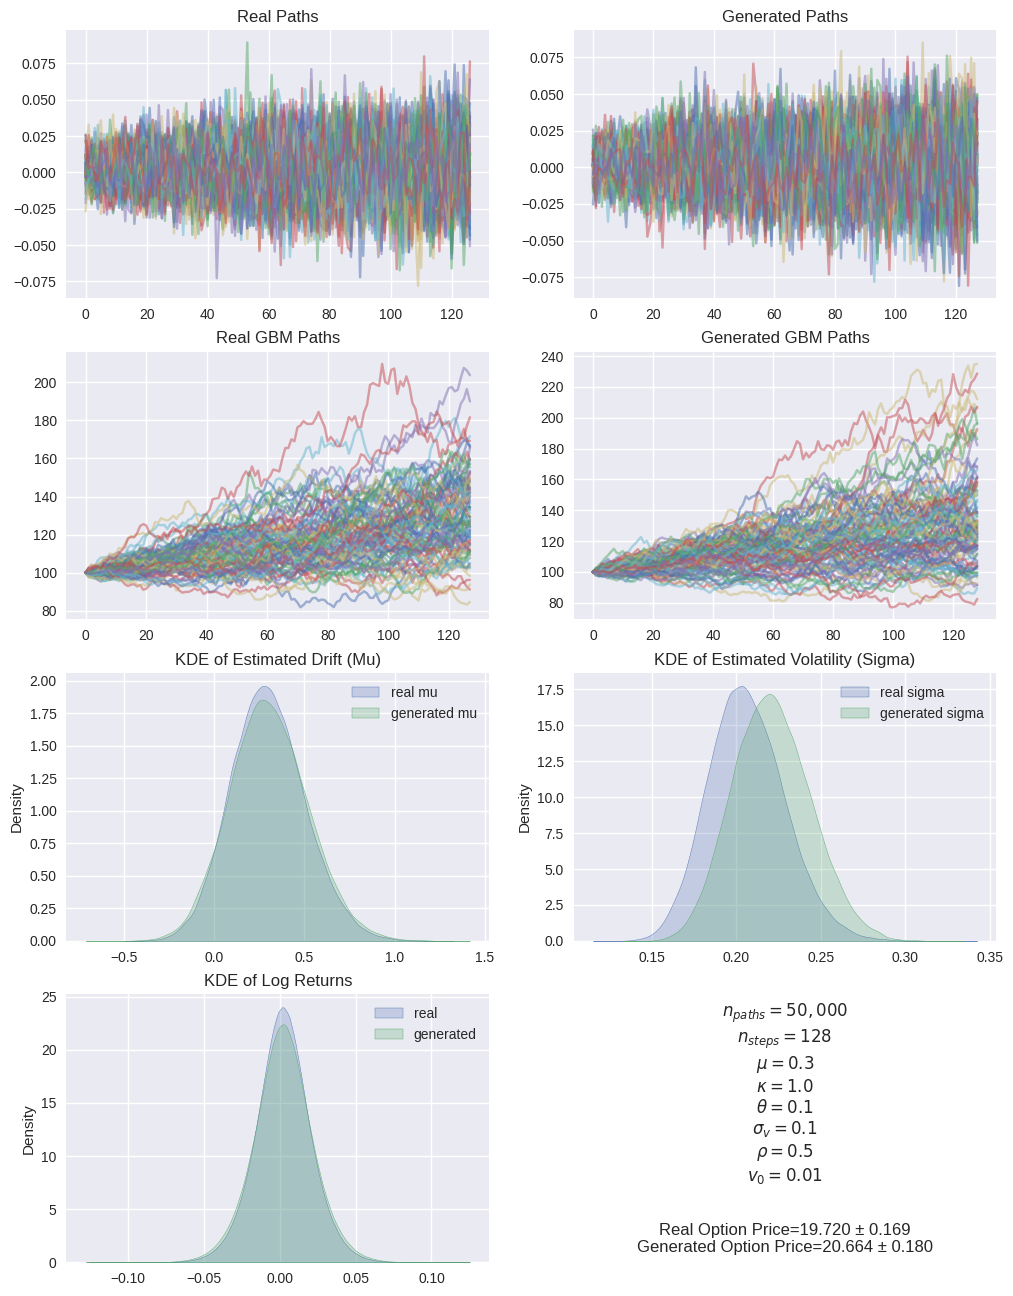

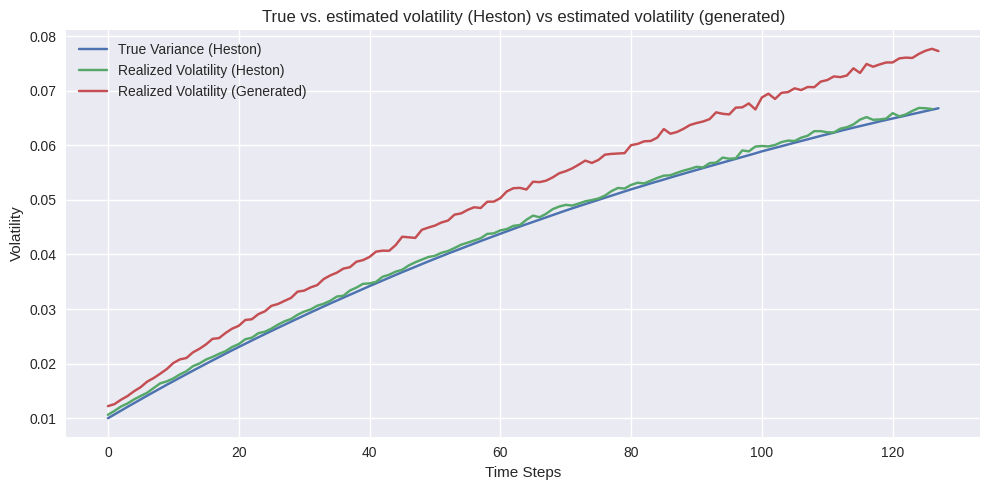

In [131]:
filepaths = [
    # '../out_train_ts/00038-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-ao6pE/generated_samples/generated_paths.npy',
    # '../out_train_ts/00040-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-DZ3U5/generated_samples/generated_paths.npy',
    # '../out_train_ts/00041-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-42HA2/generated_samples/generated_paths.npy',
    # '../out_unet2d/00001-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch8-fp32-MtTih/generated_samples/generated_paths.npy',
    # '../out_train_ts/00034-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-5cNfv/generated_samples/generated_paths.npy'
    # '../out_unet2d/00000-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch8-fp32-0jSzw/generated_samples/generated_paths.npy',
    # '../out_train_ts/00041-GBMGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch32-fp32-42HA2/generated_samples/generated_paths.npy',
    '../out_watgpu/00028-HestonGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch64-fp32-O0hyF/generated_samples/generated_paths.npy'

]
normalizations = [
    # None,
    # 'global_mean',
    # 'global_zscore'
    # None,
    # 'global_zscore'
    # 'global_zscore',
    # 'global_zscore'
    'global_zscore'
]

for path, norm_ in zip(filepaths, normalizations):
    process_data(path, norm_, stochastic_model=stochastic_model)

In [132]:
# dataset = HestonGenerativeDataset(
#     mu=mu,
#     n_steps=n_steps,
#     n_paths=n_paths,
#     kappa=kappa,
#     theta=theta,
#     sigma_v=sigma_v,
#     rho=rho,
#     v0=v0,
# )
# real = dataset.paths.squeeze()
# generated = np.load('../out_watgpu/00028-HestonGenerativeDataset-uncond-ddpmpp-edm-gpus1-batch64-fp32-O0hyF/generated_samples/generated_paths.npy')
# real.shape, generated.shape

In [133]:
# generated_unnorm = generated * np.std(real) + np.mean(real)